# 5a - AM SDR Demod (Envelope)

SDR-Capture/Replay nach dem Prinzip aus Labor 3, danach AM-Hüllkurvendemodulation.

In [1]:
import json
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio, display

plt.rcParams['figure.figsize'] = (11, 4)
plt.rcParams['axes.grid'] = True

In [2]:
# Parameter
CENTER_FREQ_HZ = 434.0e6
SAMPLE_RATE_HZ = 2.048e6
GAIN_DB = 20.0
TOTAL_SAMPLES = 262_144*4

REPLAY = True
REPLAY_FILE = Path('recordings') / 'am_sdr_replay.json'

# Optionale FFT-Fensterung gegen Leakage
USE_FFT_WINDOW = True
FFT_WINDOW_KIND = 'hann'  # 'hann' | 'hamming' | 'rect'

def setup_rtlsdr_driver_path() -> None:
    driver_dir = None
    for p in [Path.cwd()] + list(Path.cwd().parents):
        cand = p / 'rtl-sdr-driver'
        if cand.exists() and (cand / 'librtlsdr.dll').exists():
            driver_dir = cand
            break
    if driver_dir is not None:
        os.environ['PATH'] = str(driver_dir) + os.pathsep + os.environ.get('PATH', '')
        try:
            os.add_dll_directory(str(driver_dir))
        except Exception:
            pass
        print('RTL-SDR Treiber gefunden:', driver_dir)
    else:
        print('Hinweis: rtl-sdr-driver nicht gefunden, ggf. Fallback-Signal wird genutzt.')

def capture_iq_or_fallback(center_hz: float, fs_hz: float, gain_db: float, total_samples: int) -> np.ndarray:
    setup_rtlsdr_driver_path()
    try:
        from rtlsdr import RtlSdr
        sdr = RtlSdr()
        sdr.sample_rate = fs_hz
        sdr.center_freq = center_hz
        sdr.gain = gain_db
        iq = sdr.read_samples(total_samples)
        sdr.close()
        return np.asarray(iq, dtype=np.complex64)
    except Exception as ex:
        print('RTL-SDR nicht verfügbar, nutze synthetischen Fallback:', ex)
        t = np.arange(total_samples, dtype=np.float64) / fs_hz
        f_car = 40_000.0
        f_mod = 1_000.0
        m = 0.6
        env = 1 + m * np.cos(2*np.pi*f_mod*t)
        x = env * np.cos(2*np.pi*f_car*t)
        noise = 0.02 * np.random.randn(total_samples)
        return (x + noise + 1j*0.0).astype(np.complex64)

def save_replay_iq(path: Path, iq: np.ndarray, fs_hz: float, center_hz: float, gain_db: float) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    data = {
        'meta': {'type': 'am_sdr_iq', 'version': 1},
        'sample_rate_hz': fs_hz,
        'center_freq_hz': center_hz,
        'gain_db': gain_db,
        'iq_re': np.real(iq).astype(float).tolist(),
        'iq_im': np.imag(iq).astype(float).tolist(),
    }
    path.write_text(json.dumps(data, indent=2), encoding='utf-8')

def load_replay_iq(path: Path) -> np.ndarray:
    data = json.loads(path.read_text(encoding='utf-8'))
    re = np.asarray(data['iq_re'], dtype=np.float32)
    im = np.asarray(data['iq_im'], dtype=np.float32)
    return (re + 1j*im).astype(np.complex64)

In [3]:
# Capture oder Replay
if REPLAY and REPLAY_FILE.exists():
    iq = load_replay_iq(REPLAY_FILE)
    print('Replay-IQ geladen:', REPLAY_FILE)
else:
    iq = capture_iq_or_fallback(CENTER_FREQ_HZ, SAMPLE_RATE_HZ, GAIN_DB, TOTAL_SAMPLES)
    save_replay_iq(REPLAY_FILE, iq, SAMPLE_RATE_HZ, CENTER_FREQ_HZ, GAIN_DB)
    print('Replay-IQ gespeichert:', REPLAY_FILE)

if iq.size < TOTAL_SAMPLES:
    raise RuntimeError(f'Zu wenige Samples: {iq.size} < {TOTAL_SAMPLES}')
iq = iq[:TOTAL_SAMPLES]
s = np.real(iq).astype(np.float64)
fs = float(SAMPLE_RATE_HZ)
t = np.arange(len(s)) / fs
print(f'N={len(s)}, fs={fs:.1f} Hz')

RTL-SDR Treiber gefunden: /Users/johannes/Library/CloudStorage/OneDrive-FHJOANNEUM/Kommunikationstechnologien/KT-course/KT-course/rtl-sdr-driver
RTL-SDR nicht verfügbar, nutze synthetischen Fallback: No module named 'pkg_resources'
Replay-IQ gespeichert: recordings/am_sdr_replay.json
N=1048576, fs=2048000.0 Hz


In [7]:
# IMPLEMENTIERE HIER Envelope-Demod: Gleichrichtung + Sliding-Averager
# Empfangenes Funksignal von SDR bzw. File: s
# Demoduliertes Signal; x_demod ist zu berechnen!

f_lp = 2_000.0 # Beispiel für Fensterbreite für Tiefpassfilter
N_win = max(3, int(round(fs / max(1.0, f_lp))))  # Anzahl der bins im averager, um f_lp zu erzielen
if N_win % 2 == 0:    # Fensterbreite soll ungerade sein
    N_win += 1

# Gleichrichtung
x_rect = np.abs(s)

# Sliding-Averager-Tiefpass
h = np.ones(N_win, dtype=np.float64) / N_win
x_env = np.convolve(x_rect, h, mode='same')

# DC-Anteil entfernen
x_demod = x_env - np.mean(x_env)

print(f'N_win={N_win}, f_lp~{f_lp:.1f} Hz')

N_win=1025, f_lp~2000.0 Hz


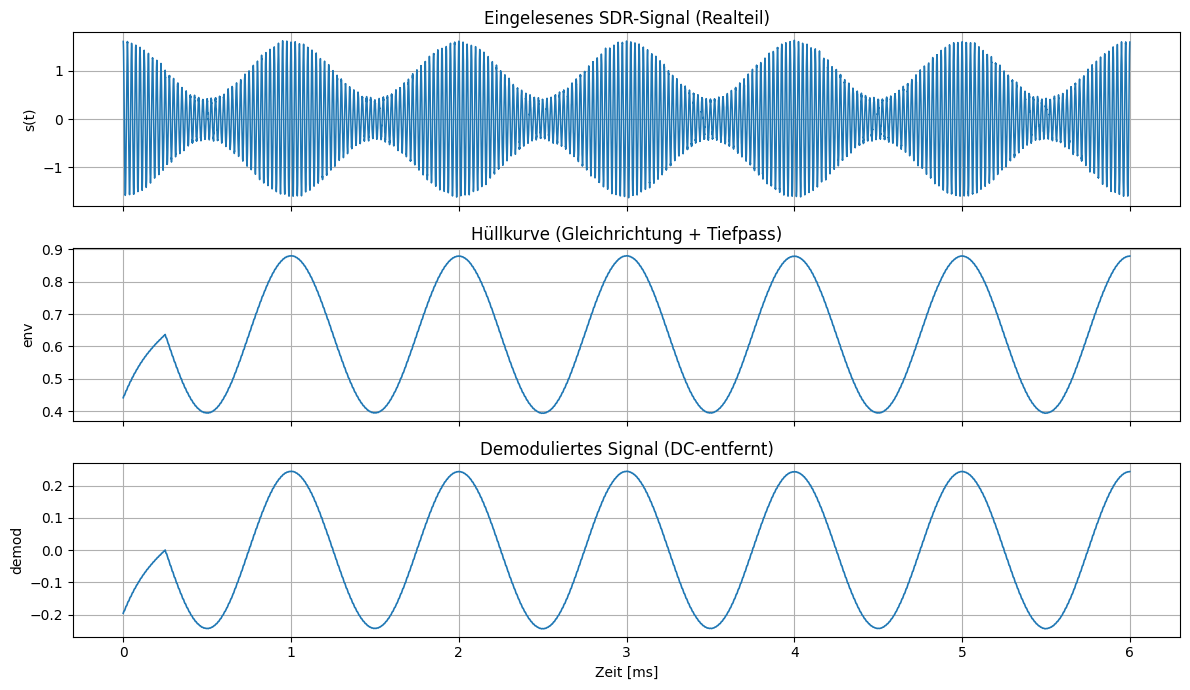

In [8]:
# Plots
t_plot_ms = 6.0
n_plot = min(len(s), int(t_plot_ms*1e-3*fs))

fig, ax = plt.subplots(3, 1, figsize=(12, 7), sharex=True)
ax[0].plot(t[:n_plot]*1e3, s[:n_plot], lw=1.1)
ax[0].set_title('Eingelesenes SDR-Signal (Realteil)')
ax[0].set_ylabel('s(t)')

ax[1].plot(t[:n_plot]*1e3, x_env[:n_plot], lw=1.2)
ax[1].set_title('Hüllkurve (Gleichrichtung + Tiefpass)')
ax[1].set_ylabel('env')

ax[2].plot(t[:n_plot]*1e3, x_demod[:n_plot], lw=1.2)
ax[2].set_title('Demoduliertes Signal (DC-entfernt)')
ax[2].set_ylabel('demod')
ax[2].set_xlabel('Zeit [ms]')
plt.tight_layout(); plt.show()

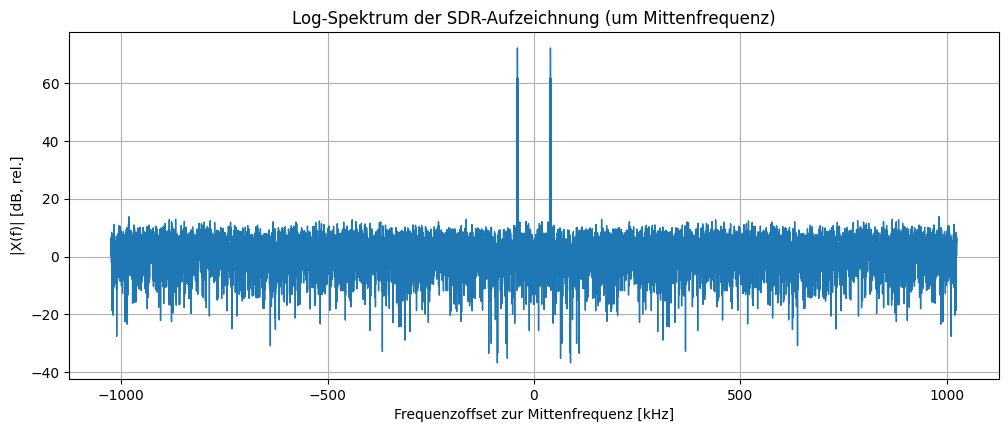

In [9]:
# Log-Spektrum der aufgenommenen SDR-Daten (Qualitätscheck der Funkaufzeichnung)
N_fft_spec = 16384
x_spec = iq[:N_fft_spec]

if USE_FFT_WINDOW:
    if FFT_WINDOW_KIND == 'hann':
        w_spec = np.hanning(N_fft_spec)
    elif FFT_WINDOW_KIND == 'hamming':
        w_spec = np.hamming(N_fft_spec)
    else:
        w_spec = np.ones(N_fft_spec)
else:
    w_spec = np.ones(N_fft_spec)

X = np.fft.fftshift(np.fft.fft(x_spec * w_spec, n=N_fft_spec))
f_rel = np.fft.fftshift(np.fft.fftfreq(N_fft_spec, d=1/fs))
S_db = 20*np.log10(np.maximum(np.abs(X), 1e-12))

plt.figure(figsize=(12, 4.5))
plt.plot(f_rel/1e3, S_db, lw=1.0)
plt.title('Log-Spektrum der SDR-Aufzeichnung (um Mittenfrequenz)')
plt.xlabel('Frequenzoffset zur Mittenfrequenz [kHz]')
plt.ylabel('|X(f)| [dB, rel.]')
plt.show()

In [10]:
# Audio (48 kS/s, zyklisch)
fs_audio = 48_000
duration_s = 4.0
t_src = np.arange(len(x_demod)) / fs
n_dst = int(round(len(x_demod) * fs_audio / fs))
t_dst = np.arange(n_dst) / fs_audio
x_audio_base = np.interp(t_dst, t_src, x_demod)
n_target = int(duration_s * fs_audio)
x_audio = np.tile(x_audio_base, int(np.ceil(n_target / len(x_audio_base))))[:n_target]
x_audio = x_audio / max(1e-12, np.max(np.abs(x_audio)))
display(Audio(x_audio, rate=fs_audio))